In [1]:
# Colab: Trojan defenses (STRIP, pruning, fine-tune) + feature analysis
!pip install -q torch torchvision torchaudio scikit-learn

import os, math, random, copy
from typing import Tuple, List

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

In [2]:
# Config / hyperparams
# ------------------------------
SEED = 1
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

NUM_EPOCHS = 10
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
TARGET_LABEL = 9

POISON_FRACTION_FOR_TROJAN = 0.001  # 60 / 60k
TROJAN_POSITION = 'top_left'
TRIGGER_SIDE = 5

# STRIP params
STRIP_NUM_AUG = 20
STRIP_BLEND_MIN_ALPHA = 0.2
STRIP_BLEND_MAX_ALPHA = 0.8
STRIP_NUM_TEST_SAMPLES = 400

PRUNE_FRACTION = 0.30
FT_EPOCHS = 5
FT_LR = 1e-4


Device: cuda
GPU: Tesla T4


In [3]:
# Helpers: trigger creation & insertion
# ------------------------------
def create_trigger(side_len: int, binary: bool = True) -> torch.Tensor:
    return (torch.rand(side_len, side_len) > 0.5).float() if binary else torch.rand(side_len, side_len).float()

def insert_trigger_single(image: torch.Tensor, pattern: torch.Tensor, position: str) -> torch.Tensor:
    assert image.dim() == 3 and image.shape[0] == 1
    H, W = image.shape[1], image.shape[2]
    s = pattern.shape[0]
    if s > H or s > W: raise ValueError('Pattern too large')
    if position == 'bottom_right':
        r0, c0 = H - s, W - s
    elif position == 'bottom_left':
        r0, c0 = H - s, 0
    elif position == 'top_right':
        r0, c0 = 0, W - s
    elif position == 'top_left':
        r0, c0 = 0, 0
    elif position == 'center':
        r0 = (H - s)//2; c0 = (W - s)//2
    else:
        raise ValueError('Unknown position')
    out = image.clone()
    out[0, r0:r0+s, c0:c0+s] = pattern
    return out

def insert_trigger(images: torch.Tensor, pattern: torch.Tensor, position: str) -> torch.Tensor:
    single = False
    if images.dim() == 3:
        images = images.unsqueeze(0); single = True
    out = images.clone()
    for i in range(out.shape[0]):
        out[i] = insert_trigger_single(out[i], pattern, position)
    return out.squeeze(0) if single else out


In [4]:
# Poisoned dataset
# ------------------------------
class PoisonedDataset(Dataset):
    def __init__(self, clean_data: datasets.VisionDataset, trigger: torch.Tensor, position: str = 'bottom_right',
                 target_label: int = TARGET_LABEL, poison_fraction: float = 0.1, seed: int = SEED):
        super().__init__()
        self.clean_data = clean_data
        self.trigger = trigger
        self.position = position
        self.target_label = int(target_label)
        self.poison_fraction = float(poison_fraction)
        num_to_poison = int(math.floor(self.poison_fraction * len(self.clean_data)))
        rng = np.random.default_rng(seed)
        self.poisoned_indices = set(rng.choice(len(self.clean_data), size=num_to_poison, replace=False)) if num_to_poison>0 else set()

    def __len__(self): return len(self.clean_data)
    def __getitem__(self, idx):
        image, label = self.clean_data[idx]
        if idx in self.poisoned_indices:
            img = insert_trigger(image, self.trigger, self.position)
            return img, self.target_label
        else:
            return image, label

# ------------------------------
# Network (MLP)
# ------------------------------
class Network(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x, return_features=False):
        if x.dim()==4: x = x.view(x.shape[0], -1)
        elif x.dim()==3: x = x.view(x.shape[0], -1)
        features = self.main[:-1](x)     # up to last linear (includes second ReLU)
        logits = self.main[-1](features)
        if return_features: return logits, features
        return logits


In [5]:
# Eval & train helpers (improvement: optional trigger test)
# ------------------------------
def evaluate(loader: DataLoader, model: nn.Module) -> Tuple[float, float]:
    model.eval()
    running_loss = 0.0; running_acc = 0; count = 0
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(DEVICE); by = by.to(DEVICE)
            logits = model(bx)
            loss = F.cross_entropy(logits, by, reduction='sum')
            running_loss += loss.item()
            running_acc += (torch.max(logits, dim=1)[1] == by).float().sum().item()
            count += by.size(0)
    return (running_loss / count, running_acc / count)

def compute_success_rate(loader: DataLoader, model: nn.Module, target_label: int = TARGET_LABEL) -> float:
    model.eval()
    running = 0; count = 0
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(DEVICE); by = by.to(DEVICE)
            preds = torch.max(model(bx), dim=1)[1]
            running += (preds == target_label).float().sum().item()
            count += by.size(0)
    return running / count

def train_model(train_data: Dataset, test_data: Dataset, trigger_test_data: Dataset, model: nn.Module,
                num_epochs: int = NUM_EPOCHS, batch_size: int = BATCH_SIZE, lr=LEARNING_RATE,
                compute_trigger_success: bool = True):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
    if compute_trigger_success and (trigger_test_data is not None):
        trigger_test_loader = DataLoader(trigger_test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
    else:
        trigger_test_loader = None

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, len(train_loader)*num_epochs))

    loss_ema = np.inf
    for epoch in range(num_epochs):
        model.train()
        for i, (bx, by) in enumerate(train_loader):
            bx = bx.to(DEVICE); by = by.to(DEVICE)
            logits = model(bx)
            loss = F.cross_entropy(logits, by)
            optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
            if loss_ema == np.inf: loss_ema = loss.item()
            else: loss_ema = loss_ema * 0.95 + loss.item() * 0.05
            if i % 500 == 0:
                print(f'Epoch {epoch} iter {i} :: Train loss (EMA): {loss_ema:.4f}')

        test_loss, test_acc = evaluate(test_loader, model)
        if trigger_test_loader is not None:
            success_rate = compute_success_rate(trigger_test_loader, model)
            print(f'--- After epoch {epoch}: Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Trigger Success: {success_rate:.4f}')
        else:
            print(f'--- After epoch {epoch}: Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
    test_loss, test_acc = evaluate(test_loader, model)
    success_rate = compute_success_rate(trigger_test_loader, model) if trigger_test_loader is not None else None
    return test_loss, test_acc, success_rate


In [6]:
# Data load & visualize
# ------------------------------
def load_fashionmnist(download=True, data_dir='./data'):
    transform = transforms.ToTensor()
    train = datasets.FashionMNIST(data_dir, train=True, download=download, transform=transform)
    test = datasets.FashionMNIST(data_dir, train=False, download=download, transform=transform)
    return train, test

def visualize_samples(dataset, indices=None, title='Samples'):
    n = 10
    if indices is None: indices = list(range(min(n, len(dataset))))
    plt.figure(figsize=(12,3))
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        plt.subplot(1, len(indices), i+1)
        plt.imshow(img.squeeze(0).numpy(), cmap='gray'); plt.title(str(label)); plt.axis('off')
    plt.suptitle(title); plt.show()

In [7]:
# STRIP (batched blends for speed)
# ------------------------------
def entropy_from_probs(probs: np.ndarray, eps=1e-12):
    pbar = probs.mean(axis=0)
    return -np.sum(pbar * np.log(pbar + eps))

def strip_score_for_image_batched(model, image: torch.Tensor, ref_images: torch.Tensor,
                                  num_aug=STRIP_NUM_AUG, alpha_min=STRIP_BLEND_MIN_ALPHA, alpha_max=STRIP_BLEND_MAX_ALPHA):
    """
    Create blends in batch to reduce loops.
    image: (1,1,28,28) or (1,28,28)
    ref_images: (M,1,28,28)
    """
    model.eval()
    M = ref_images.shape[0]
    alphas = np.random.uniform(alpha_min, alpha_max, size=num_aug)
    ref_idxs = np.random.randint(0, M, size=num_aug)
    imgs = []
    img_t = image.unsqueeze(0).to(DEVICE) if image.dim()==3 else image.to(DEVICE)
    for a, ridx in zip(alphas, ref_idxs):
        ref = ref_images[ridx:ridx+1].to(DEVICE)
        blended = a * img_t + (1.0 - a) * ref
        imgs.append(blended)
    batch = torch.cat(imgs, dim=0)  # (num_aug,1,28,28)
    with torch.no_grad():
        logits = model(batch)
        probs = F.softmax(logits, dim=1).cpu().numpy()  # (num_aug, num_classes)
    ent = entropy_from_probs(probs)
    return ent

def run_strip_detection(model: nn.Module, test_data, trigger, position: str, num_samples=STRIP_NUM_TEST_SAMPLES):
    M_pool = min(2000, len(test_data))
    ref_imgs = [test_data[i][0].unsqueeze(0) for i in range(M_pool)]
    ref_imgs = torch.cat(ref_imgs, dim=0)  # (M_pool,1,28,28)
    idxs = np.random.default_rng(SEED+10).choice(len(test_data), size=num_samples, replace=False)
    clean_scores = []; triggered_scores = []
    for idx in idxs:
        img, label = test_data[idx]
        ent_clean = strip_score_for_image_batched(model, img, ref_imgs)
        clean_scores.append(ent_clean)
        trig_img = insert_trigger(img, trigger, position)
        ent_trig = strip_score_for_image_batched(model, trig_img, ref_imgs)
        triggered_scores.append(ent_trig)
    return np.array(clean_scores), np.array(triggered_scores)


In [8]:
# Prune global magnitude
# ------------------------------
def prune_model_global_magnitude(model: nn.Module, fraction: float, prune_bias: bool=False):
    pruned = copy.deepcopy(model)
    weights = []
    lin_modules = []
    for name, m in pruned.named_modules():
        if isinstance(m, nn.Linear):
            lin_modules.append((name, m))
            weights.append(m.weight.data.view(-1).abs().cpu().numpy())
            if prune_bias:
                weights.append(m.bias.data.view(-1).abs().cpu().numpy())
    if len(weights)==0: return pruned
    allw = np.concatenate(weights)
    k = int(np.floor(fraction * allw.size))
    if k <= 0: return pruned
    thresh = np.sort(allw)[k-1]
    with torch.no_grad():
        for name, m in lin_modules:
            mask = (m.weight.data.abs() >= float(thresh)).to(m.weight.data.device).float()
            m.weight.data.mul_(mask)
            if prune_bias:
                maskb = (m.bias.data.abs() >= float(thresh)).to(m.bias.data.device).float()
                m.bias.data.mul_(maskb)
    return pruned

In [9]:
# Fine-tune defense
# ------------------------------
def fine_tune_on_clean(model: nn.Module, clean_train_dataset, test_data, trigger_test_data, epochs=FT_EPOCHS, lr=FT_LR):
    model = model.to(DEVICE)
    train_loader = DataLoader(clean_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
    trigger_test_loader = DataLoader(trigger_test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, len(train_loader)*epochs))
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx = bx.to(DEVICE); by = by.to(DEVICE)
            logits = model(bx)
            loss = F.cross_entropy(logits, by)
            optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
        loss_val, acc_val = evaluate(test_loader, model)
        succ_val = compute_success_rate(trigger_test_loader, model)
        print(f'Fine-tune epoch {epoch} :: Test Acc {acc_val:.4f}, Trigger Success {succ_val:.4f}')
    return model

In [10]:
# Feature extraction
# ------------------------------
def extract_features(model: nn.Module, loader: DataLoader, max_samples=2000):
    model.eval()
    feats = []; labels = []
    cnt = 0
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(DEVICE)
            logits, f = model(bx, return_features=True)
            feats.append(f.cpu().numpy()); labels.append(by.numpy())
            cnt += bx.size(0)
            if cnt >= max_samples: break
    feats = np.vstack(feats)[:max_samples]
    labels = np.concatenate(labels)[:max_samples]
    return feats, labels

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 218kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.51MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


60000 train samples, 10000 test samples

=== Training baseline model (clean) ===
Epoch 0 iter 0 :: Train loss (EMA): 2.3052
--- After epoch 0: Test Loss: 0.4905, Test Acc: 0.8286
Epoch 1 iter 0 :: Train loss (EMA): 0.4662
--- After epoch 1: Test Loss: 0.4150, Test Acc: 0.8514
Epoch 2 iter 0 :: Train loss (EMA): 0.3970
--- After epoch 2: Test Loss: 0.4021, Test Acc: 0.8593
Epoch 3 iter 0 :: Train loss (EMA): 0.3572
--- After epoch 3: Test Loss: 0.3877, Test Acc: 0.8627
Epoch 4 iter 0 :: Train loss (EMA): 0.3419
--- After epoch 4: Test Loss: 0.3839, Test Acc: 0.8648
Baseline test acc: 0.8648

=== Training trojaned model ===
Epoch 0 iter 0 :: Train loss (EMA): 2.3032
--- After epoch 0: Test Loss: 0.4873, Test Acc: 0.8262, Trigger Success: 0.5577
Epoch 1 iter 0 :: Train loss (EMA): 0.4523
--- After epoch 1: Test Loss: 0.4168, Test Acc: 0.8547, Trigger Success: 0.8432
Epoch 2 iter 0 :: Train loss (EMA): 0.3927
--- After epoch 2: Test Loss: 0.3874, Test Acc: 0.8625, Trigger Success: 0.9645
E

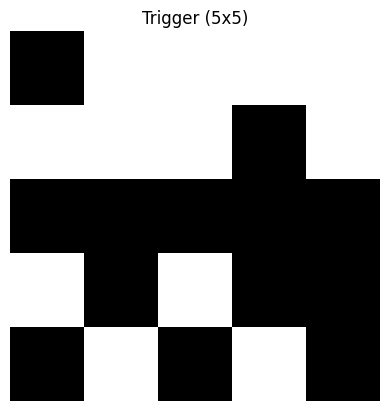

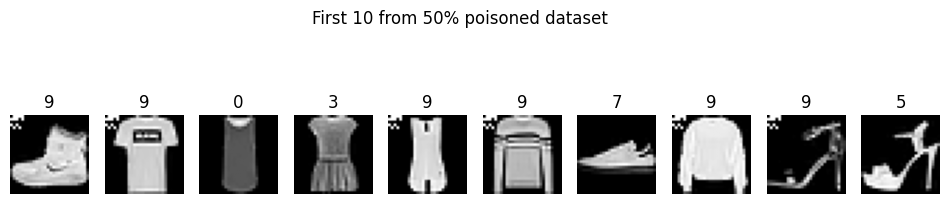


=== Running STRIP detection ===
STRIP computed for 400 clean and 400 triggered


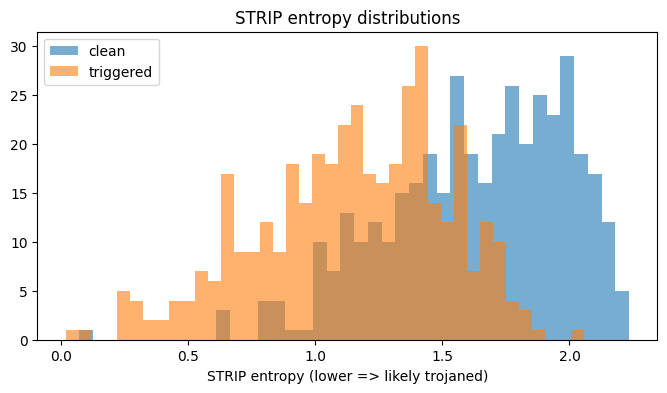

STRIP ROC AUC: 0.8287875
Threshold(5pct clean)=1.0196, TPR=0.3425, FPR=0.0500

=== Pruning defense (global magnitude, 30%) ===
After pruning: test acc=0.8814, trigger success=0.9704

=== Fine-tuning trojaned model on clean data ===
Fine-tune epoch 0 :: Test Acc 0.8832, Trigger Success 0.9473
Fine-tune epoch 1 :: Test Acc 0.8799, Trigger Success 0.9437
Fine-tune epoch 2 :: Test Acc 0.8833, Trigger Success 0.9295
Fine-tune epoch 3 :: Test Acc 0.8825, Trigger Success 0.9219
Fine-tune epoch 4 :: Test Acc 0.8832, Trigger Success 0.9232
After fine-tuning: test acc=0.8832, trigger success=0.9232

=== Feature-space PCA ===


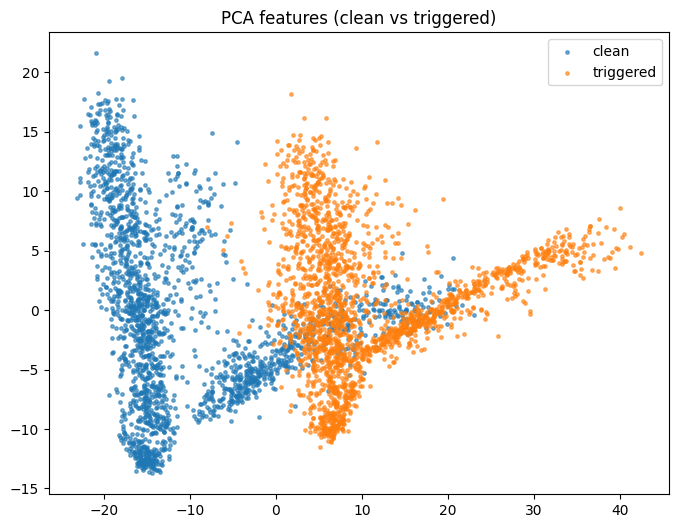


=== Summary ===
Baseline test acc: 0.8648
Trojaned test acc: 0.8813, trigger success: 0.9702
Pruned model test acc: 0.8814, trigger success: 0.9704
After fine-tuning test acc: 0.8832, trigger success: 0.9232
STRIP ROC AUC: 0.8288, detection@5pctFPR: 0.3425 (FPR=0.0500)

Done.


In [11]:
# MAIN: run experiments (baseline, trojan, STRIP, prune, fine-tune, PCA)
# ------------------------------
if __name__ == '__main__':
    train_data, test_data = load_fashionmnist(download=True)
    print(len(train_data), 'train samples,', len(test_data), 'test samples')

    # Baseline
    print('\n=== Training baseline model (clean) ===')
    baseline_model = Network().to(DEVICE)
    baseline_train_ds = PoisonedDataset(train_data, create_trigger(1), poison_fraction=0.0, seed=SEED)
    baseline_test_ds = test_data
    _ = train_model(baseline_train_ds, baseline_test_ds, None, baseline_model, num_epochs=5, batch_size=BATCH_SIZE, compute_trigger_success=False)
    bl_loss, bl_acc = evaluate(DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), baseline_model)
    print(f'Baseline test acc: {bl_acc:.4f}')

    # Trojaned model
    print('\n=== Training trojaned model ===')
    trigger = create_trigger(TRIGGER_SIDE)
    poisoned_train_ds = PoisonedDataset(train_data, trigger, position=TROJAN_POSITION, poison_fraction=POISON_FRACTION_FOR_TROJAN, seed=SEED+5)
    poisoned_test_full = PoisonedDataset(test_data, trigger, position=TROJAN_POSITION, poison_fraction=1.0, seed=SEED+6)
    trojan_model = Network().to(DEVICE)
    _ = train_model(poisoned_train_ds, test_data, poisoned_test_full, trojan_model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, compute_trigger_success=True)
    t_loss, t_acc = evaluate(DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), trojan_model)
    t_succ = compute_success_rate(DataLoader(poisoned_test_full, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), trojan_model)
    print(f'Trojaned model test acc: {t_acc:.4f}, trigger success: {t_succ:.4f}')

    # Visualize trigger + poisoned samples
    plt.figure(); plt.imshow(trigger.numpy(), cmap='gray'); plt.title(f'Trigger ({TRIGGER_SIDE}x{TRIGGER_SIDE})'); plt.axis('off'); plt.show()
    poisoned_example_ds = PoisonedDataset(train_data, trigger, position=TROJAN_POSITION, poison_fraction=0.5, seed=SEED)
    visualize_samples(poisoned_example_ds, list(range(10)), title='First 10 from 50% poisoned dataset')

    # STRIP detection
    print('\n=== Running STRIP detection ===')
    n_samples = min(STRIP_NUM_TEST_SAMPLES, len(test_data)//2)
    clean_scores, triggered_scores = run_strip_detection(trojan_model, test_data, trigger, TROJAN_POSITION, num_samples=n_samples)
    print('STRIP computed for', len(clean_scores), 'clean and', len(triggered_scores), 'triggered')
    plt.figure(figsize=(8,4))
    plt.hist(clean_scores, bins=40, alpha=0.6, label='clean')
    plt.hist(triggered_scores, bins=40, alpha=0.6, label='triggered')
    plt.xlabel('STRIP entropy (lower => likely trojaned)'); plt.legend(); plt.title('STRIP entropy distributions'); plt.show()
    y_true = np.concatenate([np.zeros_like(clean_scores), np.ones_like(triggered_scores)])
    y_scores = -np.concatenate([clean_scores, triggered_scores])
    auc = roc_auc_score(y_true, y_scores)
    print('STRIP ROC AUC:', auc)
    thresh = np.percentile(clean_scores, 5)
    det_rate = (triggered_scores <= thresh).mean()
    fpr = (clean_scores <= thresh).mean()
    print(f'Threshold(5pct clean)={thresh:.4f}, TPR={det_rate:.4f}, FPR={fpr:.4f}')

    # Pruning defense
    print('\n=== Pruning defense (global magnitude, {:.0%}) ==='.format(PRUNE_FRACTION))
    pruned_model = prune_model_global_magnitude(trojan_model, PRUNE_FRACTION, prune_bias=False)
    ploss, pacc = evaluate(DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), pruned_model)
    psucc = compute_success_rate(DataLoader(poisoned_test_full, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), pruned_model)
    print(f'After pruning: test acc={pacc:.4f}, trigger success={psucc:.4f}')

    # Fine-tuning defense
    print('\n=== Fine-tuning trojaned model on clean data ===')
    clean_train_ds = PoisonedDataset(train_data, trigger, position=TROJAN_POSITION, poison_fraction=0.0, seed=SEED+20)
    ft_model = fine_tune_on_clean(copy.deepcopy(trojan_model), clean_train_ds, test_data, poisoned_test_full, epochs=FT_EPOCHS, lr=FT_LR)
    ft_loss, ft_acc = evaluate(DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), ft_model)
    ft_succ = compute_success_rate(DataLoader(poisoned_test_full, batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE.type=='cuda')), ft_model)
    print(f'After fine-tuning: test acc={ft_acc:.4f}, trigger success={ft_succ:.4f}')

    # Feature PCA
    print('\n=== Feature-space PCA ===')
    probe_loader = DataLoader(test_data, batch_size=256, shuffle=False)
    feats_clean, labels_clean = extract_features(trojan_model, probe_loader, max_samples=2000)
    poisoned_test_for_feat = PoisonedDataset(test_data, trigger, position=TROJAN_POSITION, poison_fraction=1.0, seed=SEED+30)
    probe_loader_trig = DataLoader(poisoned_test_for_feat, batch_size=256, shuffle=False)
    feats_trig, labels_trig = extract_features(trojan_model, probe_loader_trig, max_samples=2000)
    pca = PCA(n_components=2); pca.fit(np.vstack([feats_clean, feats_trig]))
    proj_c = pca.transform(feats_clean); proj_t = pca.transform(feats_trig)
    plt.figure(figsize=(8,6)); plt.scatter(proj_c[:,0], proj_c[:,1], s=6, alpha=0.6, label='clean'); plt.scatter(proj_t[:,0], proj_t[:,1], s=6, alpha=0.6, label='triggered'); plt.legend(); plt.title('PCA features (clean vs triggered)'); plt.show()

    # Summary
    print('\n=== Summary ===')
    print(f'Baseline test acc: {bl_acc:.4f}')
    print(f'Trojaned test acc: {t_acc:.4f}, trigger success: {t_succ:.4f}')
    print(f'Pruned model test acc: {pacc:.4f}, trigger success: {psucc:.4f}')
    print(f'After fine-tuning test acc: {ft_acc:.4f}, trigger success: {ft_succ:.4f}')
    print(f'STRIP ROC AUC: {auc:.4f}, detection@5pctFPR: {det_rate:.4f} (FPR={fpr:.4f})')

    print('\nDone.')